# Netflix Dataset Analysis Documentation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('netflix_titles.csv')

### 1. Data Loading

The `netflix_titles.csv` dataset is loaded into a pandas DataFrame using `pd.read_csv()`. Essential libraries `pandas` and `matplotlib.pyplot` are imported for data manipulation and visualization.

In [ ]:
print(df.shape)
df=df[~(df['rating'].str.contains('min',na=False))]

(8807, 12)


### 2. Initial Data Inspection and Preprocessing

The shape of the DataFrame is printed to understand its dimensions. Rows where the 'rating' column contains 'min' (likely indicating duration rather than content rating) are removed to clean the data.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8804 non-null   object
 1   type          8804 non-null   object
 2   title         8804 non-null   object
 3   director      6170 non-null   object
 4   cast          7979 non-null   object
 5   country       7973 non-null   object
 6   date_added    8794 non-null   object
 7   release_year  8804 non-null   int64 
 8   rating        8800 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8804 non-null   object
 11  description   8804 non-null   object
dtypes: int64(1), object(11)
memory usage: 894.2+ KB
None


The `df.info()` method provides a concise summary of the DataFrame, including the data types of each column and the count of non-null values, which is crucial for identifying missing data.

In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           0
listed_in          0
description        0
dtype: int64


The `df.isnull().sum()` method is used to count the number of missing values in each column. This helps in understanding the extent of missing data before imputation.

In [ ]:
print(df.duplicated().sum())#no duplicate rows

0


The dataset is checked for duplicate rows using `df.duplicated().sum()`. In this case, no duplicate rows were found, indicating a clean dataset regarding unique entries.

In [ ]:
df['director'].fillna('unknown',inplace=True)
df['cast'].fillna('not available',inplace=True)
df['country'].fillna('unknown',inplace=True)
df['date_added'].fillna('unknown',inplace=True)
df['rating'].fillna(df['rating'].mode()[0],inplace=True)#filling rating nan cells with mean
df['duration'].fillna(df['duration'].mode()[0],inplace=True)#filling duration nan cells with mean

/tmp/ipykernel_1565/2268396542.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('unknown',inplace=True)
/tmp/ipykernel_1565/2268396542.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

### 3. Handling Missing Values

Missing values in several key columns (`director`, `cast`, `country`, `date_added`, `rating`, `duration`) are handled. Categorical columns like `director`, `cast`, `country`, and `date_added` are filled with 'unknown' or 'not available'. For `rating` and `duration`, missing values are imputed with the mode of their respective columns to preserve common values.

In [ ]:
print(df.isnull().sum())#no null rows

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


After imputation, `df.isnull().sum()` is run again to verify that all missing values have been successfully addressed.

In [ ]:
#trim all cells with strings
for c in df.columns:
  if(df[c].dtype=='object'):
    df[c]=df[c].str.strip()


### 4. Data Cleaning: Trimming and Lowercasing Strings

All object (string) columns in the DataFrame are iterated through. For each string column, `str.strip()` is applied to remove leading and trailing whitespace, and `str.lower()` is applied to convert all text to lowercase. This ensures consistency and facilitates accurate analysis and comparison of string data.

In [ ]:
#lower all cells with strings
for c in df.columns:
  if(df[c].dtype=='object'):
    df[c]=df[c].str.lower()


Continuing the string cleaning, this cell explicitly converts all string values in object-type columns to lowercase, which is vital for standardized text analysis and avoiding issues with case sensitivity.

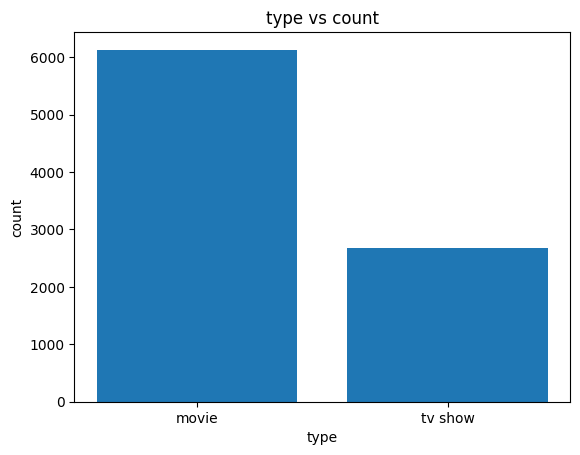

In [ ]:
#how many movies vs tv-shows
type_vs_count=pd.DataFrame(df.groupby('type').count()['show_id'])
# print(type(type_vs_count))

plt.bar(type_vs_count.index,type_vs_count.iloc[:,0])
plt.xlabel('type')
plt.ylabel('count')
plt.title('type vs count')
plt.show()

### 5. Content Type Distribution

This section analyzes the distribution of content types (movies versus TV shows). A bar chart is generated to visually represent the count of each type, providing a clear comparison of the volume of movies versus TV shows on Netflix.

Index(['g', 'nc-17', 'nr', 'pg', 'pg-13', 'r', 'tv-14', 'tv-g', 'tv-ma',
       'tv-pg', 'tv-y', 'tv-y7', 'tv-y7-fv', 'ur'],
      dtype='object', name='rating')


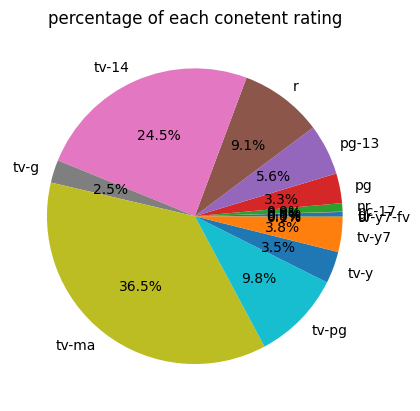

In [ ]:
#percentage of each conetent rating
res=df.groupby('rating').count()['show_id']
print(res.index)
plt.pie(res,labels=res.index,autopct='%1.1f%%',)
plt.title('percentage of each conetent rating')
plt.show()

### 6. Content Rating Distribution

A pie chart is used to visualize the percentage distribution of different content ratings (e.g., 'tv-ma', 'pg-13') across the dataset. This helps in understanding the prevalent content classifications.

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1031
2018    1147
2019    1030
2020     953
2021     592
Name: show_id, Length: 74, dtype: int64


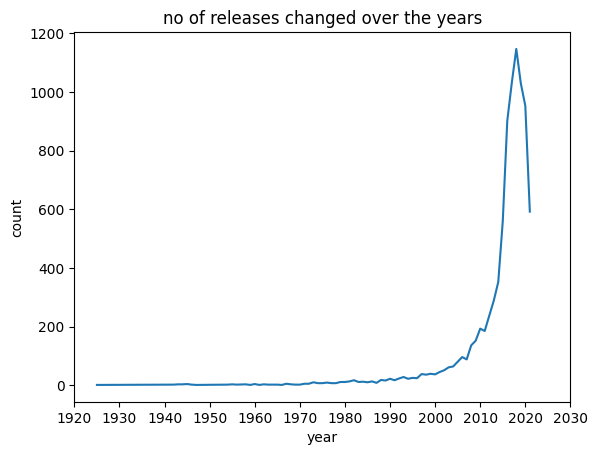

In [ ]:
#no of releases changed over the years
res=df.groupby('release_year').count()['show_id']
print(res)
plt.plot(res.index,res)
plt.xticks(range(1920,2031,10))
plt.xlabel('year')
plt.ylabel('count')
plt.title('no of releases changed over the years')
plt.show()


### 7. Releases Over the Years

This plot shows the trend of content releases over time. A line plot illustrates how the number of `show_id` entries (releases) has changed from 1925 to 2021, providing insights into the historical growth of content on Netflix.

duration
1 season      1793
10 min           1
10 seasons       7
100 min        108
101 min        116
              ... 
95 min         137
96 min         130
97 min         146
98 min         120
99 min         118
Name: show_id, Length: 220, dtype: int64


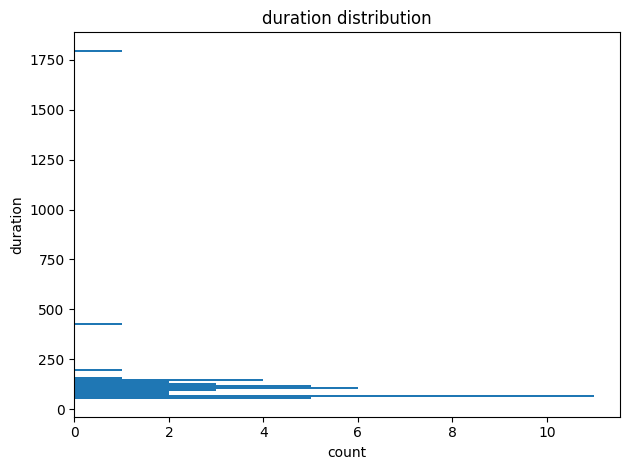

In [ ]:
res=df.groupby('duration').count()['show_id']
print(res)
plt.hist(res,bins=range(50,max(res)+11,10),orientation='horizontal')
plt.ylabel('duration')
plt.xlabel('count')
plt.title('duration distribution')
plt.tight_layout()
plt.show()

### 8. Duration Distribution

This histogram visualizes the distribution of content durations. By grouping and counting `show_id` entries by their `duration`, it provides an overview of how many titles fall into different duration categories.

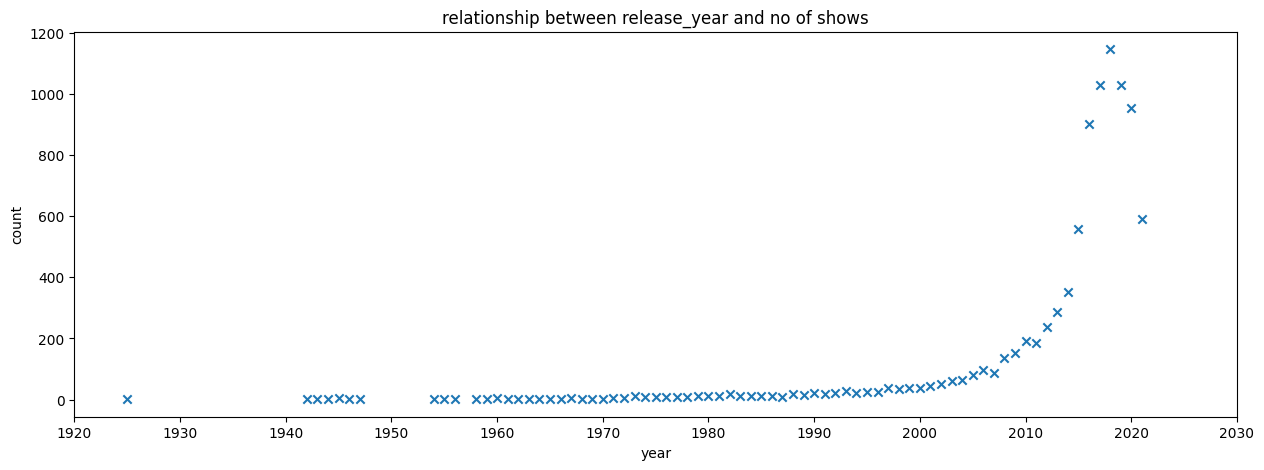

In [ ]:
#relationship between release_year and no of shows
res=df.groupby('release_year').count()['show_id']
plt.figure(figsize=(15, 5))
plt.scatter(res.index,res,marker='x')
plt.xticks(range(1920,2031,10))
plt.xlabel('year')
plt.ylabel('count')
plt.title('relationship between release_year and no of shows')
plt.show()

### 10. Relationship Between Release Year and Number of Shows

This scatter plot further explores the relationship between the `release_year` and the total number of shows released. It complements the previous line plot by showing individual data points, which can help in identifying specific years with unusual release counts.

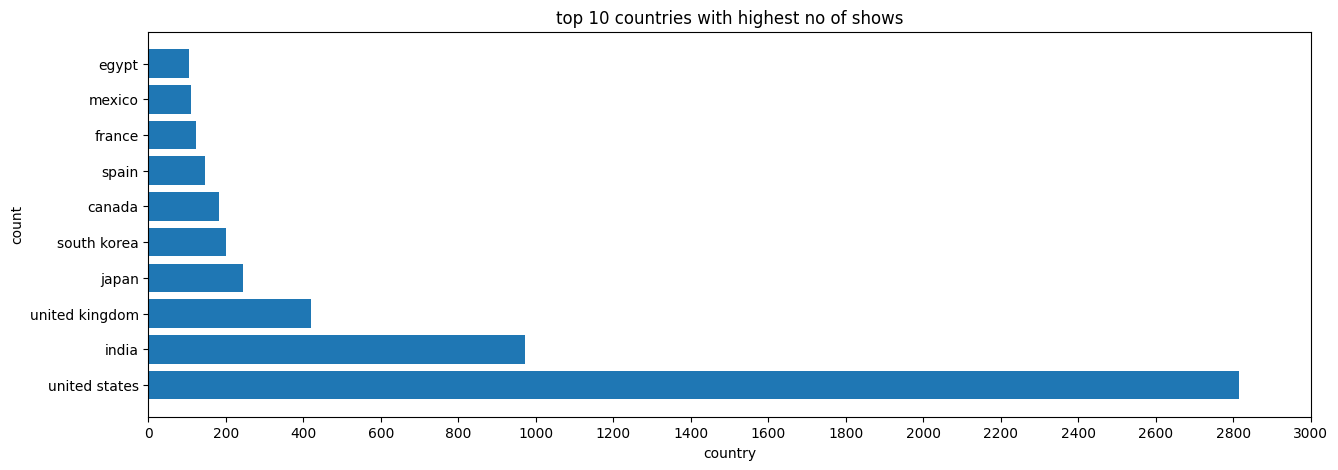

In [ ]:
#top 10 countries with highest no of shows
res=df['country'].explode().value_counts()
res=res[res.index!='unknown']
res=res.sort_values(ascending=False)[:10]
plt.figure(figsize=(15, 5))
plt.barh(res.index,res,)
plt.xlabel('country')
plt.ylabel('count')
plt.xticks(range(0,3100,200))
plt.title('top 10 countries with highest no of shows')
plt.show()

### 9. Top 10 Countries by Content Production

This bar chart identifies and displays the top 10 countries with the highest number of shows or movies on Netflix. Countries categorized as 'unknown' are excluded from this analysis to focus on identifiable origins. The horizontal bar chart provides an easy-to-read comparison of content contributions by country.

type          movie  tv show
release_year                
1925            0.0      1.0
1942            2.0      0.0
1943            3.0      0.0
1944            3.0      0.0
1945            3.0      1.0
...             ...      ...
2017          766.0    265.0
2018          767.0    380.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0

[74 rows x 2 columns]


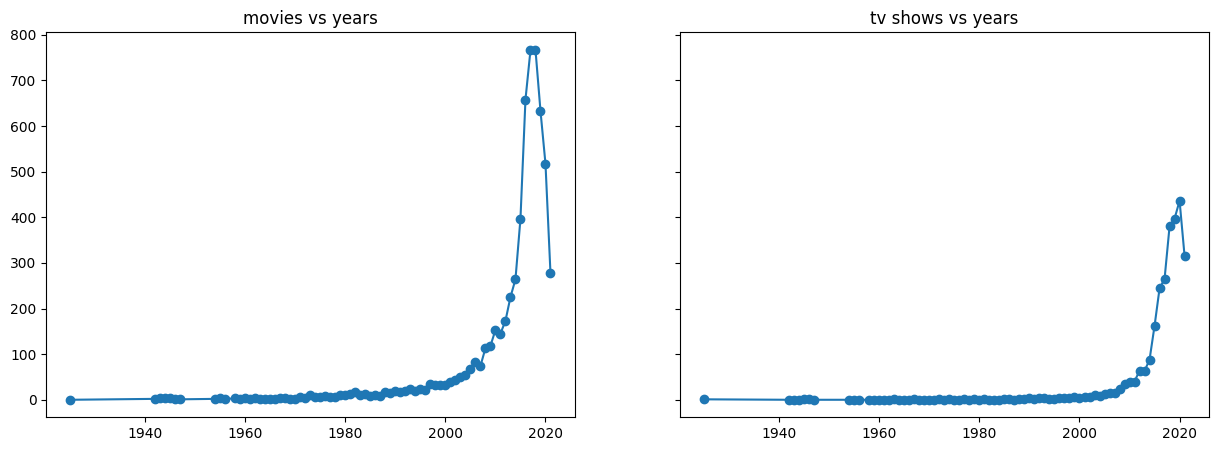

In [ ]:
#movies ,tv shows vs years
res=df.groupby(['release_year','type']).count()['show_id'].unstack().fillna(0)
print(res)
fig,ax=plt.subplots(1,2,figsize=(15,5),sharey=True)
ax[0].plot(res.index,res['movie'],marker='o')
ax[1].plot(res.index,res['tv show'],marker='o')
ax[0].set_title('movies vs years')
ax[1].set_title('tv shows vs years')
plt.show()

### 11. Movie and TV Show Releases vs. Years

This section provides a detailed view of movie and TV show releases over the years. Two separate line plots are generated side-by-side, allowing for a direct comparison of the historical trends for movies and TV shows independently.